# Week 10 - More on Regression Models
This week, you will learn to run a Multiple Regression Model.  When you are trying to predict a continuous variable you are building a regression model.
Attribute Information:

- longitude             block group latitude
- latitude              block group latitude
- housing_median_age    median house age in block group
- total_rooms           Total rooms
- total_bedrooms        Total bedrooms
- population            block group population
- households            No of households per block
- median_income         median income in block group
- median_house_value    median house value
- ocean_proximity       How close to ocean


In [328]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as so

In [329]:
# Read in the dataset
california = pd.read_csv("housing.csv")
california.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Delete Duplicate records

In [330]:
california_dup = california[california.duplicated(keep = 'first')]
if california_dup.size != 0:
    california.drop_duplicates(keep = 'first', ignore_index = True, inplace = True)
california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# Feature Engineering

In [331]:
california['rooms_per_house'] = california['total_rooms']/california['households']
california['bedrooms_per_household'] = california['total_bedrooms']/california['households']

In [332]:
california['Avg_pop_household'] = california['population']/california['households']

# Delete Duplicate information
Since we use total_rooms and total_bedrooms to compute 'Avg_bedroom_household' and "Avg_rooms_household"

In [333]:
# Delete Duplicate data information
LD = ['total_rooms', 'total_bedrooms', 'households']
california.drop(columns = LD, axis = 1, inplace = True)

# Number of Missing Values

In [334]:
california.isnull().sum()

longitude                   0
latitude                    0
housing_median_age          0
population                  0
median_income               0
median_house_value          0
ocean_proximity             0
rooms_per_house             0
bedrooms_per_household    207
Avg_pop_household           0
dtype: int64

# Housing price capped at $500,001 Delete theses values from the data set

In [335]:
california = california[california['median_house_value'] < 500001.0]
california.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19675 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   longitude               19675 non-null  float64
 1   latitude                19675 non-null  float64
 2   housing_median_age      19675 non-null  float64
 3   population              19675 non-null  float64
 4   median_income           19675 non-null  float64
 5   median_house_value      19675 non-null  float64
 6   ocean_proximity         19675 non-null  object 
 7   rooms_per_house         19675 non-null  float64
 8   bedrooms_per_household  19475 non-null  float64
 9   Avg_pop_household       19675 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


# Ocean proximity
Houses close to the ocean have higher median housing prices.  Let look at the distribution of the houses near the ocean.


In [336]:
california['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64

In [337]:
california = california[california['ocean_proximity'] != 'ISLAND']
california['ocean_proximity'].value_counts(normalize = True) * 100

ocean_proximity
<1H OCEAN     43.741739
INLAND        33.167260
NEAR OCEAN    12.435180
NEAR BAY      10.655821
Name: proportion, dtype: float64

# Nominal Column to stratify the data in training and test data sets.
The ocean_proximity has no missing values, it can be used to stratify the data to make sure there are the same amount of ocean.

In [338]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(california, test_size = 0.30, stratify = california['ocean_proximity'], random_state = 42)

In [339]:
train_df['ocean_proximity'].value_counts(normalize = True) * 100

ocean_proximity
<1H OCEAN     43.743191
INLAND        33.168712
NEAR OCEAN    12.433728
NEAR BAY      10.654369
Name: proportion, dtype: float64

In [340]:
test_df['ocean_proximity'].value_counts(normalize = True) * 100

ocean_proximity
<1H OCEAN     43.738349
INLAND        33.163871
NEAR OCEAN    12.438570
NEAR BAY      10.659210
Name: proportion, dtype: float64

In [341]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13769 entries, 710 to 13692
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   longitude               13769 non-null  float64
 1   latitude                13769 non-null  float64
 2   housing_median_age      13769 non-null  float64
 3   population              13769 non-null  float64
 4   median_income           13769 non-null  float64
 5   median_house_value      13769 non-null  float64
 6   ocean_proximity         13769 non-null  object 
 7   rooms_per_house         13769 non-null  float64
 8   bedrooms_per_household  13627 non-null  float64
 9   Avg_pop_household       13769 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.2+ MB


In [342]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5901 entries, 10212 to 8693
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   longitude               5901 non-null   float64
 1   latitude                5901 non-null   float64
 2   housing_median_age      5901 non-null   float64
 3   population              5901 non-null   float64
 4   median_income           5901 non-null   float64
 5   median_house_value      5901 non-null   float64
 6   ocean_proximity         5901 non-null   object 
 7   rooms_per_house         5901 non-null   float64
 8   bedrooms_per_household  5843 non-null   float64
 9   Avg_pop_household       5901 non-null   float64
dtypes: float64(9), object(1)
memory usage: 507.1+ KB


# Exploring the Training Data set
It is now time to explore the training dataset<br>
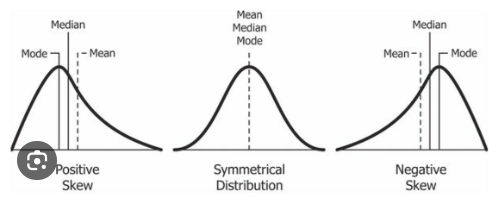

In [343]:
n_cols = train_df.select_dtypes(include = np.number).columns
train_df.describe().T


,count,mean,std,min,25%,50%,75%,max
longitude,13769.0,-119.557913,1.998734,-124.350000,-121.750000,-118.510000,-117.990000,-114.310000
latitude,13769.0,35.647900,2.146144,32.550000,33.930000,34.270000,37.720000,41.950000
housing_median_age,13769.0,28.370978,12.477391,1.000000,18.000000,28.000000,37.000000,52.000000
population,13769.0,1435.273876,1106.554689,3.000000,796.000000,1177.000000,1741.000000,28566.000000
median_income,13769.0,3.678667,1.571536,0.499900,2.532600,3.440800,4.573500,15.000100
median_house_value,13769.0,192477.565401,97496.551821,14999.000000,117100.000000,174100.000000,248200.000000,500000.000000
rooms_per_house,13769.0,5.342082,2.037541,0.846154,4.412752,5.181501,5.962343,62.422222
bedrooms_per_household,13627.0,1.092928,0.376441,0.333333,1.004951,1.048193,1.098866,14.111111
Avg_pop_household,13769.0,3.111536,11.946886,0.692308,2.447191,2.835351,3.308958,1243.333333


In [344]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13769 entries, 710 to 13692
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   longitude               13769 non-null  float64
 1   latitude                13769 non-null  float64
 2   housing_median_age      13769 non-null  float64
 3   population              13769 non-null  float64
 4   median_income           13769 non-null  float64
 5   median_house_value      13769 non-null  float64
 6   ocean_proximity         13769 non-null  object 
 7   rooms_per_house         13769 non-null  float64
 8   bedrooms_per_household  13627 non-null  float64
 9   Avg_pop_household       13769 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.2+ MB


# Distribution of the variables

```
dataframe['column'].plot(kind = 'hist', y = 'column', color = 'b', edgecolor = 'k', title = 'column description', figsize = (5, 5), bins = 25);
```


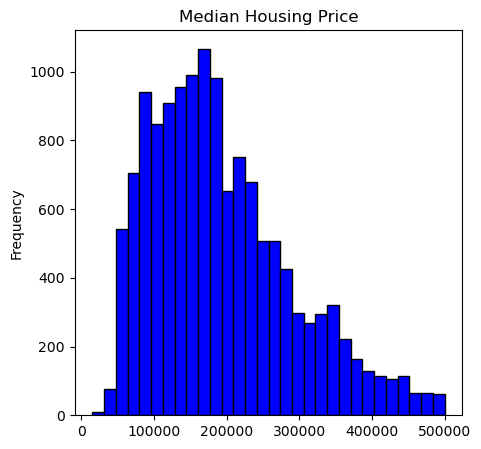

In [345]:
train_df['median_house_value'].plot(kind = 'hist', y = 'median_house_value', color = 'b', edgecolor = 'k', title = 'Median Housing Price', figsize =(5,5), bins = 30);

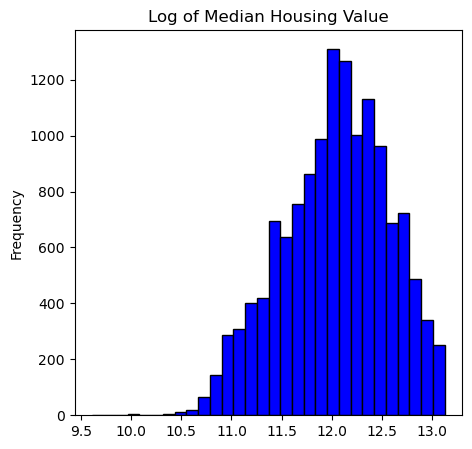

In [346]:
train_df['log_mhv'] = np.log(train_df['median_house_value'])
train_df['log_mhv'].plot(kind = 'hist', y = 'log_mhv', color = 'b', edgecolor = 'k', title = 'Log of Median Housing Value', figsize =(5,5), bins = 30);

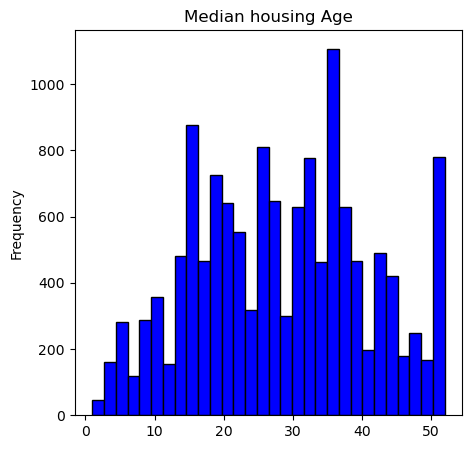

In [347]:
train_df['housing_median_age'].plot(kind = 'hist', y = 'housing_median_age', color = 'b', edgecolor = 'k', title = 'Median housing Age', figsize =(5,5), bins = 30);

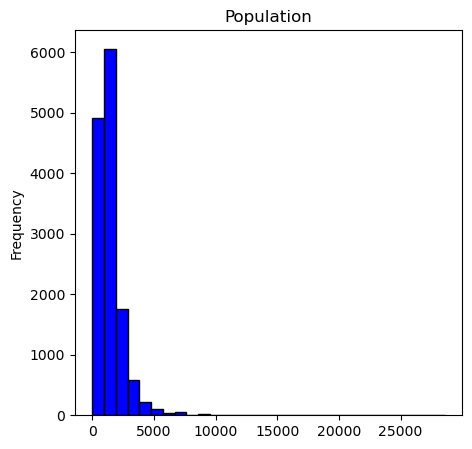

In [348]:
train_df['population'].plot(kind = 'hist', y = 'population', color = 'b', edgecolor = 'k', title = 'Population', figsize =(5,5), bins = 30);

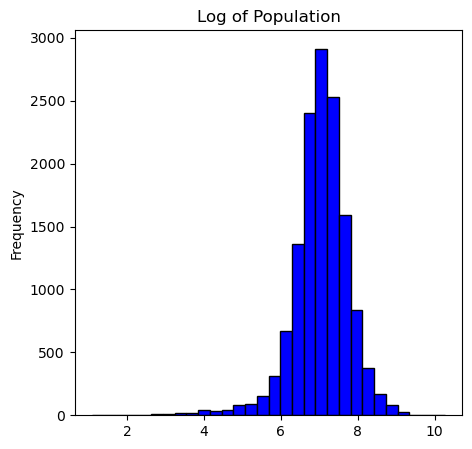

In [349]:
train_df['log_pop'] = np.log(train_df['population'])
train_df['log_pop'].plot(kind = 'hist', y = 'log_pop', color = 'b', edgecolor = 'k', title = 'Log of Population', figsize =(5,5), bins = 30);

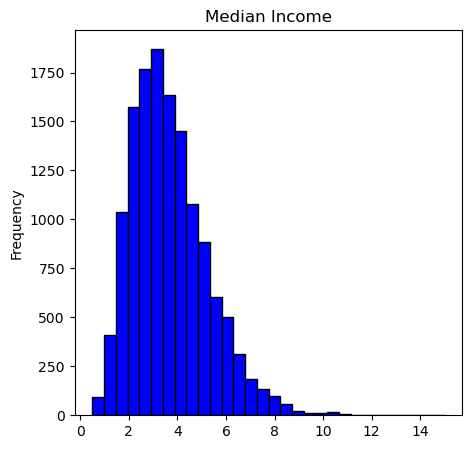

In [350]:
train_df['median_income'].plot(kind = 'hist', y = 'median_income', color = 'b', edgecolor = 'k', title = 'Median Income', figsize =(5,5), bins = 30);

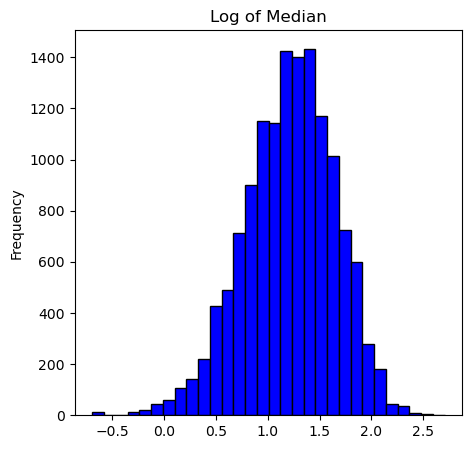

In [351]:
train_df['log_mi'] = np.log(train_df['median_income'])
train_df['log_mi'].plot(kind = 'hist', y = 'log_mi', color = 'b', edgecolor = 'k', title = 'Log of Median', figsize =(5,5), bins = 30);

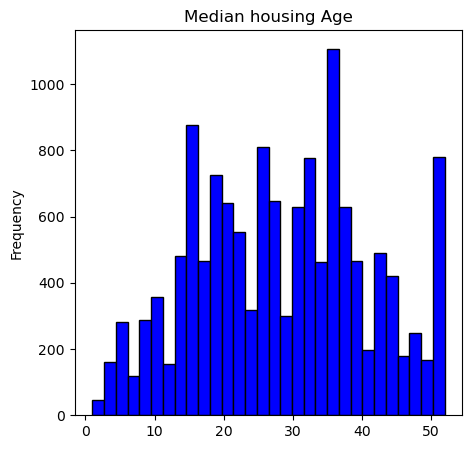

In [352]:
train_df['housing_median_age'].plot(kind = 'hist', y = 'housing_median_age', color = 'b', edgecolor = 'k', title = 'Median housing Age', figsize =(5,5), bins = 30);

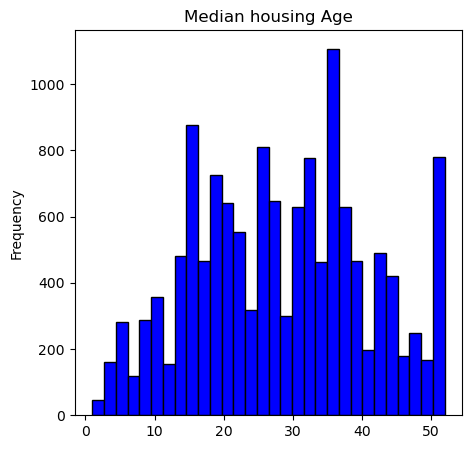

In [353]:
train_df['housing_median_age'].plot(kind = 'hist', y = 'housing_median_age', color = 'b', edgecolor = 'k', title = 'Median housing Age', figsize =(5,5), bins = 30);

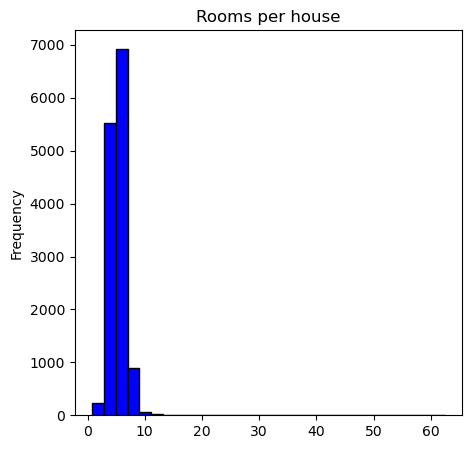

In [354]:
train_df['rooms_per_house'].plot(kind = 'hist', y = 'rooms_per_house', color = 'b', edgecolor = 'k', title = 'Rooms per house', figsize =(5,5), bins = 30);

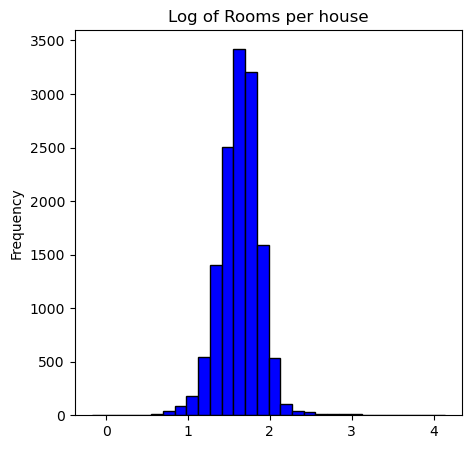

In [355]:
train_df['log_rph'] = np.log(train_df['rooms_per_house'])
train_df['log_rph'].plot(kind = 'hist', y = 'log_rph', color = 'b', edgecolor = 'k', title = 'Log of Rooms per house', figsize =(5,5), bins = 30);

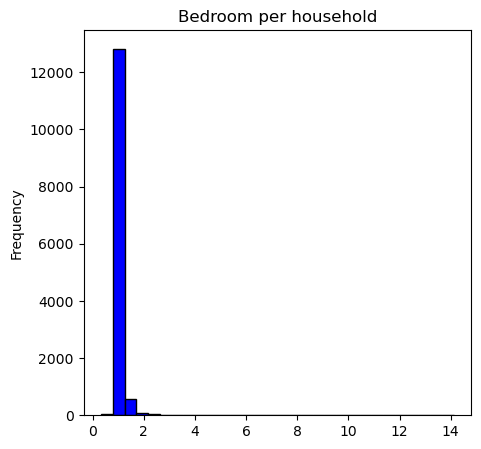

In [356]:
train_df['bedrooms_per_household'].plot(kind = 'hist', y = 'bedrooms_per_household', color = 'b', edgecolor = 'k', title = 'Bedroom per household', figsize =(5,5), bins = 30);

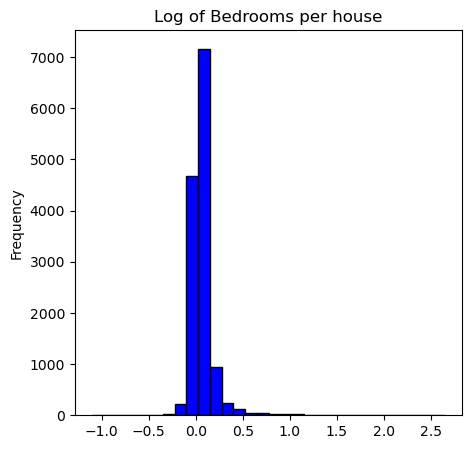

In [357]:
train_df['log_bph'] = np.log(train_df['bedrooms_per_household'])
train_df['log_bph'].plot(kind = 'hist', y = 'log_bph', color = 'b', edgecolor = 'k', title = 'Log of Bedrooms per house', figsize =(5,5), bins = 30);

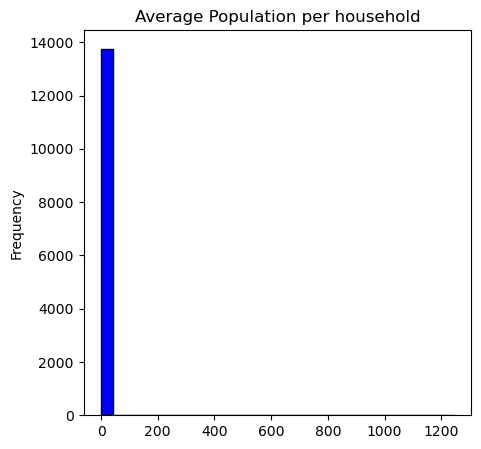

In [358]:
train_df['Avg_pop_household'].plot(kind = 'hist', y = 'Avg_pop_household', color = 'b', edgecolor = 'k', title = 'Average Population per household', figsize =(5,5), bins = 30);

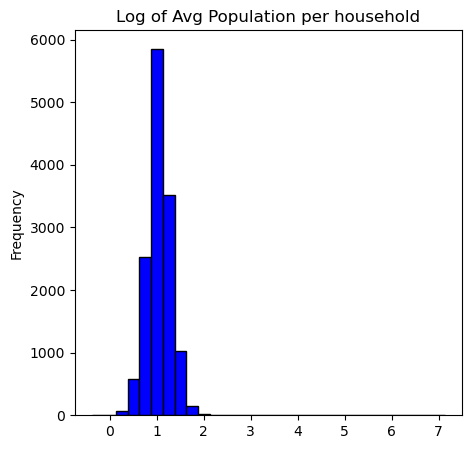

In [359]:
train_df['log_pph'] = np.log(train_df['Avg_pop_household'])
train_df['log_pph'].plot(kind = 'hist', y = np.log(train_df['Avg_pop_household']), color = 'b', edgecolor = 'k', title = 'Log of Avg Population per household', figsize =(5,5), bins = 30);

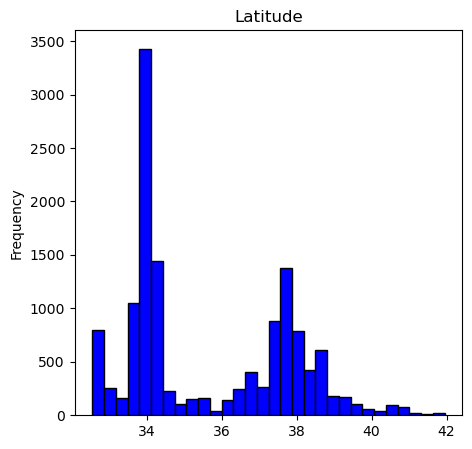

In [360]:
train_df['latitude'].plot(kind = 'hist', y = 'latitude', color = 'b', edgecolor = 'k', title = 'Latitude', figsize =(5,5), bins = 30);

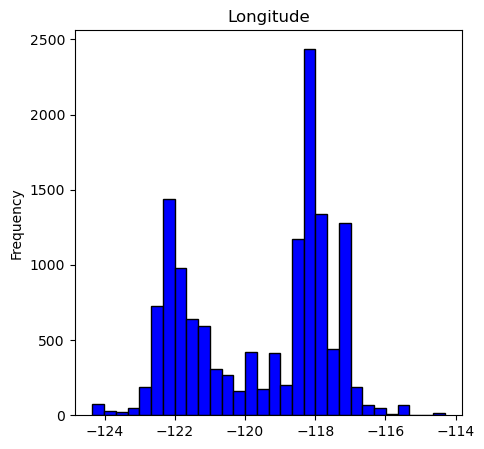

In [361]:
train_df['longitude'].plot(kind = 'hist', y = 'longitude', color = 'b', edgecolor = 'k', title = 'Longitude', figsize =(5,5), bins = 30);

# Correlation with the Median_house_value
Correlation strength scale (absolute value)

• 0.90 to 1.00 → Excellent<br>
• 0.75 to 0.90 → Strong<br>
• 0.50 to 0.75 → Moderate<br>
• 0.30 to 0.50 → Weak<br>
• 0.00 to 0.30 → Very weak to none<br>

**Remember:**<br>
• The sign (+ or –) only tells direction, not strength.<br>
• Strength is based on the absolute value.


In [362]:
n_cols = train_df.select_dtypes(include = np.number).columns
cor_matrix = train_df[n_cols].corr()
np.abs(cor_matrix['median_house_value']).sort_values(ascending = False)

median_house_value        1.000000
log_mhv                   0.953798
median_income             0.642824
log_mi                    0.614034
log_pph                   0.236341
log_rph                   0.187720
latitude                  0.148060
rooms_per_house           0.132005
log_bph                   0.101939
bedrooms_per_household    0.066953
housing_median_age        0.064266
longitude                 0.046483
log_pop                   0.027557
Avg_pop_household         0.025042
population                0.020096
Name: median_house_value, dtype: float64

# Data Visualization

<Axes: title={'center': 'Median income vs Median House Price'}, xlabel='median_income', ylabel='median_house_value'>

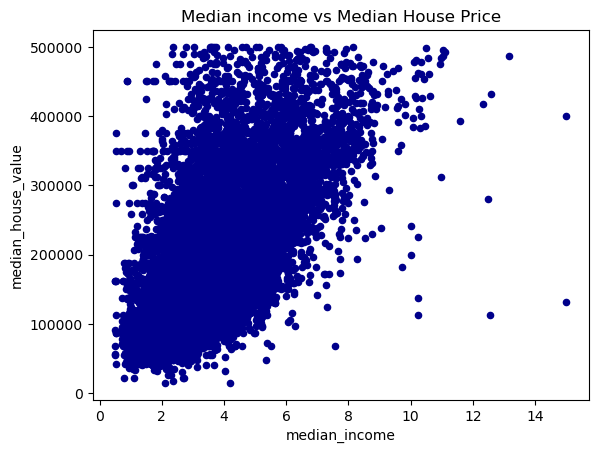

In [363]:
# Data Visualization
train_df.plot.scatter(x = 'median_income', y = 'median_house_value', c = 'DarkBlue', title = 'Median income vs Median House Price')

In [364]:
cor_matrix

,longitude,latitude,housing_median_age,population,median_income,median_house_value,rooms_per_house,bedrooms_per_household,Avg_pop_household,log_mhv,log_pop,log_mi,log_rph,log_bph,log_pph
longitude,1.000000,-0.923287,-0.102586,0.098152,-0.002225,-0.046483,-0.026703,0.018081,-0.000663,-0.017746,0.109186,-0.002417,-0.066531,0.015926,0.155859
latitude,-0.923287,1.000000,0.008791,-0.113199,-0.085858,-0.148060,0.121938,0.079776,0.007970,-0.196162,-0.141545,-0.089635,0.157471,0.097168,-0.148597
housing_median_age,-0.102586,0.008791,1.000000,-0.298165,-0.193296,0.064266,-0.200457,-0.099516,0.014405,0.040342,-0.244361,-0.182943,-0.245785,-0.138839,0.002720
population,0.098152,-0.113199,-0.298165,1.000000,0.042769,0.020096,-0.069317,-0.071676,0.071819,0.051357,0.806311,0.058538,-0.060464,-0.054743,0.196633
median_income,-0.002225,-0.085858,-0.193296,0.042769,1.000000,0.642824,0.363339,-0.083268,0.033932,0.639069,0.036183,0.956567,0.543968,-0.149337,-0.006679
median_house_value,-0.046483,-0.148060,0.064266,0.020096,0.642824,1.000000,0.132005,-0.066953,-0.025042,0.953798,0.027557,0.614034,0.187720,-0.101939,-0.236341
rooms_per_house,-0.026703,0.121938,-0.200457,-0.069317,0.363339,0.132005,1.000000,0.802528,-0.011321,0.116201,-0.145513,0.343707,0.861960,0.677367,-0.036234
bedrooms_per_household,0.018081,0.079776,-0.099516,-0.071676,-0.083268,-0.066953,0.802528,1.000000,-0.008820,-0.077417,-0.168304,-0.089886,0.474816,0.895626,-0.086810
Avg_pop_household,-0.000663,0.007970,0.014405,0.071819,0.033932,-0.025042,-0.011321,-0.008820,1.000000,-0.023468,0.042564,0.019680,-0.016712,-0.015171,0.339900
log_mhv,-0.017746,-0.196162,0.040342,0.051357,0.639069,0.953798,0.116201,-0.077417,-0.023468,1.000000,0.063497,0.643580,0.165357,-0.120585,-0.212991


In [365]:
LD = ['log_mhv', 'log_pop', 'log_mi', 'log_rph', 'log_bph', 'log_pph']
train_df.drop(columns = LD, axis = 1, inplace = True)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13769 entries, 710 to 13692
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   longitude               13769 non-null  float64
 1   latitude                13769 non-null  float64
 2   housing_median_age      13769 non-null  float64
 3   population              13769 non-null  float64
 4   median_income           13769 non-null  float64
 5   median_house_value      13769 non-null  float64
 6   ocean_proximity         13769 non-null  object 
 7   rooms_per_house         13769 non-null  float64
 8   bedrooms_per_household  13627 non-null  float64
 9   Avg_pop_household       13769 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.2+ MB


# Q1 - Separate the Features from the Target variable

In [366]:

y_train = train_df['median_house_value']
X_train = train_df.drop('median_house_value', axis = 1)

y_test = test_df['median_house_value']
X_test = test_df.drop('median_house_value', axis = 1)

# Q2 - Creating a Pipeline for Numerical Data
- from sklearn.impute import SimpleImputer
- from sklearn.preprocessing import StandardScaler, RobustScaler
- from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
- from sklearn.pipeline import Pipeline
- create the numeric column names called numeric_features
- Create a Pipeline called numeric_transformer that 
   is a imputer using SimpleImputer replacing the missing values with the mean
   is a QuantileTransformer to make the skewed data more normal and scale the data
 


In [367]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

n_features = X_train.select_dtypes(include = np.number).columns
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'mean')),  
    ('scaler', StandardScaler())])   


# Q3 - Creating a Pipeline for Categorical Data


In [368]:
c_features = X_train.select_dtypes(include = ['object']).columns
cat_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy = 'most_frequent')),
     ('onehot', OneHotEncoder(handle_unknown = 'ignore'))])

# Q4 - Creating a data preprocessing pipleine


In [369]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_transformer, n_features),
    ('cat', cat_transformer, c_features)])



# Q5 - Model Building - Linear Regression - Standard Scaler



In [370]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

l_reg = make_pipeline(preprocessor, 
                    TransformedTargetRegressor(LinearRegression(),
                    transformer = StandardScaler()))

l_reg.fit(X_train,y_train)

y_pd_train = l_reg.predict(X_train)
l_reg_rmse_train = np.sqrt(mean_squared_error(y_train, y_pd_train))

y_pd_test = l_reg.predict(X_test)
l_reg_rmse_test = np.sqrt(mean_squared_error(y_test, y_pd_test))

print("Standard Scaler")
print("Training ", l_reg_rmse_train)
print("Testing  ", l_reg_rmse_test)


Standard Scaler
Training  62962.04652969477
Testing   63593.158987691066


# Q6 - Linear Regression - Cross-Validation
- from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
- from sklearn.linear_model import Ridge, Lasso, ElasticNet
- from sklearn.ensemble import RandomForestRegressor
- create the cross_val_score * -1 raised to the 0.5 power and assign it to l_rmses_cv for training data.
- create the cross_val_score * -1 raised to the 0.5 power and assign it to l_rmse_cv_test for the test data.
- print "5-Fold Cross Validation"
- print "train data set RMSE
- print pd.Series(l_rmse_cv describe method)
- print test data set RMSE to the next line
- print pd.Series(l_rmse_cv_test describe method)

In [371]:
# Linear Regression - 
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
sc = "neg_root_mean_squared_error"
l_rmses_cv = np.sqrt(-cross_val_score(l_reg, X_train, y_train, scoring = sc, cv = 5))
l_rmses_cv_test = np.sqrt(-cross_val_score(l_reg, X_test, y_test, scoring = sc, cv = 5))
print("5-Fold Cross Validation")
print("train data set RMSE")
print(pd.Series(l_rmses_cv).describe())
print("\ntest data set RMSE")
print(pd.Series(l_rmses_cv_test).describe())

5-Fold Cross Validation
train data set RMSE
count      5.000000
mean     251.205913
std        2.976096
min      246.629957
25%      251.067155
50%      251.161735
75%      252.331468
max      254.839249
dtype: float64

test data set RMSE
count      5.000000
mean     275.742664
std       51.469592
min      247.530748
25%      251.915750
50%      254.633840
75%      257.035529
max      367.597454
dtype: float64


# Q7 - Ridge Regression Model
A regression model that uses weights close to zero to prevent overfitting. This model uses a parameter alpha which will be set to 0.1 for this example and matrix factorization technique by sag.
## **The Analogy: The "Over-Eager" Student** Imagine a student who is studying for a history test. They find a few specific facts that appeared on a practice quiz (like "The teacher wore a blue shirt on Tuesday") and they memorize them, thinking those facts will help them on the real exam.  <br>In Machine Learning, we call this Overfitting. The model is paying too much attention to small, unimportant details in the training data.<br>
## **What is Ridge Regression?**  Ridge Regression is like a strict coach for your model. It tells the model: "You can look for patterns, but I'm going to penalize you if you make any one pattern too important.<br>"In a standard regression, the model might give a massive "weight" (slope) to a feature like number of bedrooms. Ridge Regression adds a Penalty to the equation. If the model tries to make a slope too steep, the penalty gets bigger.<br>
## **The "Knob" (Alpha)** The most important part for your students to understand is the Alpha ($\alpha$) parameter. <br>Think of this as the "Volume Knob" for the penalty: Alpha = 0: The coach is asleep. The model is just a regular Linear Regression and can overfit as much as it wants.  Low Alpha: The coach is watching, but is being gentle.  High Alpha: The coach is very strict. The slopes are forced to stay very small, making the model simpler and more "stable."<br>
## Why use it?  We use Ridge Regression when we want our model to be a Good Generalizer.  We don't want the model to get a 100% on the "Practice Homework" (Training Data) but a 50% on the "Final Exam" (Test Data). Ridge Regression helps us hit that 1% Rule where the difference between the training and testing error is very small.

In [372]:
# Create the Ridge Regression Model
L1 = [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 10.0, 100.0]
param_grid = {'transformedtargetregressor__regressor__alpha': L1}

r_reg = make_pipeline(preprocessor, TransformedTargetRegressor(Ridge(),
             transformer = StandardScaler()))
grid_search = GridSearchCV(r_reg, param_grid, cv = 5, scoring = sc)
grid_search.fit(X_train, y_train)
best_index = grid_search.best_index_
print("Best Alpha found:", grid_search.best_params_)
best_alpha_value = grid_search.best_params_['transformedtargetregressor__regressor__alpha']

Best Alpha found: {'transformedtargetregressor__regressor__alpha': 0.1}


# Q8 - Ridge Regression - Cross Valuation

In [373]:
r_reg = make_pipeline(preprocessor, 
                      TransformedTargetRegressor(Ridge(alpha = best_alpha_value),
                      transformer = StandardScaler())) 
r_rmses_cv = np.sqrt(-cross_val_score(r_reg, X_train, y_train, scoring = sc, cv = 5))
r_rmses_cv_test = np.sqrt(-cross_val_score(r_reg, X_test, y_test, scoring = sc, cv = 5))
print("Ridge Regression")
print("Training Data\n", pd.Series(r_rmses_cv).describe())
print("Testing Data\n", pd.Series(r_rmses_cv_test).describe())

Ridge Regression
Training Data
 count      5.000000
mean     251.205919
std        2.976189
min      246.629878
25%      251.066868
50%      251.161990
75%      252.331385
max      254.839474
dtype: float64
Testing Data
 count      5.000000
mean     275.741665
std       51.470207
min      247.530383
25%      251.915986
50%      254.629665
75%      257.034648
max      367.597641
dtype: float64


# Q9 - Lasso Regression - Best Alpha parameter
Another regression model is a lasso regression model. This model also has a parameter alpha = 0.1. It removes some of the weights associated with the features used to predict the total_price target variable.

In [374]:
las_reg = make_pipeline(preprocessor, 
                        TransformedTargetRegressor(Lasso(),
                        transformer = StandardScaler()))
grid_search = GridSearchCV(las_reg, param_grid, cv = 5, scoring = sc)
grid_search.fit(X_train, y_train)

best_index = grid_search.best_index_
print("Best Alpha found:", grid_search.best_params_)
best_alpha_value = grid_search.best_params_['transformedtargetregressor__regressor__alpha']

Best Alpha found: {'transformedtargetregressor__regressor__alpha': 0.1}


# Q10 - Lasso Regression - Cross Validation

In [375]:
las_reg = make_pipeline(preprocessor, 
                TransformedTargetRegressor(Lasso(alpha = best_alpha_value),
                transformer = StandardScaler()))

las_rmses_cv = np.sqrt(-cross_val_score(las_reg, X_train, y_train, scoring = sc, cv = 5))

las_rmses_cv_test = np.sqrt(-cross_val_score(las_reg, X_test, y_test, scoring = sc, cv = 5))

print("Lasso Regression")
print("Training Data\n", pd.Series(las_rmses_cv).describe())
print("Testing Data\n", pd.Series(las_rmses_cv_test).describe())

Lasso Regression
Training Data
 count      5.000000
mean     262.276537
std        3.820072
min      256.736217
25%      261.661552
50%      262.536811
75%      263.004258
max      267.443850
dtype: float64
Testing Data
 count      5.000000
mean     263.818285
std        4.289275
min      259.140242
25%      261.315814
50%      263.204747
75%      265.004685
max      270.425939
dtype: float64


# Q11 - Elastic Net Regression - Best Parameter
The Elastic Net Regression is a weighted average of the Ridge Regression and the Lasso Regression. There are two parameters, alpha and l1_ratio weighted average for the lasso and ridge regression model.

In [376]:
en_reg = make_pipeline(preprocessor, 
        TransformedTargetRegressor(regressor = ElasticNet(),
        transformer = StandardScaler()))
B1 = [0.1, 0.25, 0.50, 1.0, 1.1, 1.25, 1.5, 5.0, 10.0]
C1 = [0.1, 0.2, 0.25, 0.5, 0.75, 0.8]
param_grid = {
    'transformedtargetregressor__regressor__alpha' : B1,
    'transformedtargetregressor__regressor__l1_ratio' : C1}

grid_search = GridSearchCV(en_reg, param_grid, cv=5, scoring = sc)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

# Extracting the values from the dictionary
best_alpha = float(best_params['transformedtargetregressor__regressor__alpha'])
best_l1 = float(best_params['transformedtargetregressor__regressor__l1_ratio'])
print("best alpha ", best_alpha)
print("best l1 ", best_l1)

best alpha  0.1
best l1  0.1


# Q12 - Elastic Net Regression - Cross Validation

In [377]:
enet_reg = make_pipeline(preprocessor, 
               ElasticNet(alpha = best_alpha, l1_ratio = best_l1))
enet_rmses_cv = np.sqrt(-cross_val_score(enet_reg, X_train, y_train, scoring = sc, cv = 5))
enet_rmses_cv_test = np.sqrt(-cross_val_score(enet_reg, X_test, y_test, scoring = sc, cv = 5))
print("Elastic Net Regression")
print("Training Data\n", pd.Series(enet_rmses_cv).describe())
print("Testing Data\n", pd.Series(enet_rmses_cv_test).describe())

Elastic Net Regression
Training Data
 count      5.000000
mean     253.415531
std        3.501740
min      248.415800
25%      252.372393
50%      254.085068
75%      254.092389
max      258.112004
dtype: float64
Testing Data
 count      5.000000
mean     276.396282
std       50.871474
min      249.748861
25%      252.800958
50%      254.307025
75%      257.877235
max      367.247329
dtype: float64


# Q13 - Random Forest
When other model fail to work, you can run the random forest model to see if it is any better at predicting the total_price.
## The Core Idea: The Power of the Crowd
Imagine you want to predict the price of a house.<br>
A Decision Tree is like asking one person for their opinion. They might be smart, but they might also be biased or focused on only one thing (like the number of bedrooms).<br>
A Random Forest is like asking 100 people and taking the average of all their guesses.<br>
By averaging many different opinions, the "forest" cancels out the individual mistakes (errors) of any single tree.<br>

## Why is it "Random"?
For the committee to be effective, the members can't all be exactly the same. We create variety in two ways:<br>

Random Data (Bootstrapping): We don't give every tree the same list of houses to study. We give each tree a slightly different "random sample" of the textbook.<br>

Random Features: When a tree is deciding how to split the data (like by median_income or rooms), we only let it look at a random handful of features at a time. This forces some trees to become "experts" in location, while others become "experts" in house age.<br>

## Why use it instead of Linear Regression?
In your Week 9 materials, you worked with Linear Regression, which tries to draw a straight line through the data.<br>

The Problem: Real-world data (like California housing) is often "curvy" and complex.<br>

The Solution: A Random Forest doesn't care about straight lines. It can handle complex, "zig-zag" patterns that a simple Ridge or Lasso model might miss.<br>

In [378]:
fr_reg = make_pipeline(preprocessor, 
            TransformedTargetRegressor(RandomForestRegressor(random_state=42), 
            transformer = StandardScaler()))
fr_rmses_cv = np.sqrt(-cross_val_score(fr_reg, X_train, y_train, scoring = sc, cv = 5))

fr_rmses_cv_test = np.sqrt(-cross_val_score(fr_reg, X_test, y_test, scoring = sc, cv = 5))

print("Random Forest Regression")
print("Training Data\n", pd.Series(fr_rmses_cv).describe())
print("Testing Data\n", pd.Series(fr_rmses_cv_test).describe())

Random Forest Regression
Training Data
 count      5.000000
mean     214.900818
std        1.767864
min      212.209132
25%      214.553341
50%      215.066676
75%      215.637470
max      217.037472
dtype: float64
Testing Data
 count      5.000000
mean     219.727952
std        3.358934
min      216.579568
25%      216.825240
50%      220.109118
75%      220.263750
max      224.862085
dtype: float64


In [379]:
print("Train describe")
print(y_train.describe())

Train describe
count     13769.000000
mean     192477.565401
std       97496.551821
min       14999.000000
25%      117100.000000
50%      174100.000000
75%      248200.000000
max      500000.000000
Name: median_house_value, dtype: float64


In [380]:
print('Test describe')
print(y_test.describe())

Test describe
count      5901.000000
mean     192319.487883
std       98085.690337
min       14999.000000
25%      115000.000000
50%      172200.000000
75%      248000.000000
max      500000.000000
Name: median_house_value, dtype: float64
